In [ ]:
# ------------------------
# IMPORTS
# ------------------------

import random
import numpy as np
import torch
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from src.adapt_utils import get_combined_res_df
from src.model_interface import QAOA_GPT

pd.set_option("display.max_columns", None)

In [62]:
# CONFIG
SEED = 1337
data_input_path = "./ADAPT.jl_results/test/9_nodes"
MODEL_CONFIGS = [
    dict(
        name="GPT-Feather",
        ckpt="nanoGPT/out-9_nodes_feather/gpt_ckpt_3500_feather_ar_0_95709__er_0_0.pt",
        data_dir="nanoGPT/data/9_nodes_feather",
    ),
]
N_SAMPLES = 5
MAX_TOKENS = 150

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [63]:
# ------------------------
# GRAPH UTILS
# ------------------------

def edgelist_to_nx(edgelist, n_nodes):
    G = nx.Graph()
    G.add_nodes_from(range(n_nodes))
    for u, v, w in edgelist:
        G.add_edge(u - 1, v - 1, weight=w)
    return G


def load_graphs_from_adapt(adapt_df):
    """Load unique graphs from ADAPT df (drop_duplicates on graph_name before passing)."""
    graphs, meta = [], []
    for _, row in adapt_df.iterrows():
        G = edgelist_to_nx(row["edgelist_list"], row["n_nodes"])
        graphs.append(G)
        meta.append({"graph_name": row["graph_name"]})
    return graphs, pd.DataFrame(meta)

In [64]:
# ------------------------
# MODEL UTILS
# ------------------------

def load_model(cfg):
    return QAOA_GPT(
        model_ckpt=cfg["ckpt"],
        data_dir=cfg["data_dir"],
        temp_folder="temp_data",
    )

def run_model(qaoa, graphs):
    df_model = qaoa.generate_circ_from_nx(
        graphs,
        num_samples=N_SAMPLES,
        max_new_tokens=MAX_TOKENS,
        temperature=0.1,
        top_k=200,
    )
    return qaoa.eval_circ_df_jl(df_model)

In [65]:
# ------------------------
# LOAD & AGGREGATE ADAPT
# ------------------------

adapt_df = get_combined_res_df(data_input_path, debug_limit=None)

print(f"Total ADAPT rows      : {len(adapt_df)}")
print(f"Unique graphs         : {adapt_df['graph_name'].nunique()}")
print(f"Runs per graph (mean) : {adapt_df.groupby('graph_name').size().mean():.2f}")

# Aggregate ADAPT per graph — captures mean, best, std, and layer stats
adapt_agg = adapt_df.groupby("graph_name").agg(
    adapt_ar_mean  = ("approx_ratio", "mean"),
    adapt_ar_best  = ("approx_ratio", "max"),
    adapt_ar_std   = ("approx_ratio", "std"),
    adapt_layers_mean = ("n_layers",  "mean"),
    adapt_layers_best = ("n_layers",  "min"),   # min layers = most efficient run
    adapt_n_runs   = ("run",          "count"),
).reset_index()

adapt_agg["adapt_ar_std"] = adapt_agg["adapt_ar_std"].fillna(0)  # single-run graphs → std=NaN

print(f"\nAggregated ADAPT shape: {adapt_agg.shape}")

Reading ADAPT.jl results from:
	 /home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl_results/test/9_nodes


Opening ADAPT results (9_nodes): 100%|██████████| 1/1 [00:00<00:00, 42.36it/s]


df_list len: 1


Opening graphs (9_nodes): 100%|██████████| 1/1 [00:00<00:00, 328.91it/s]

df_list len: 1
Graphs count:
g_method
erdos_renyi    100
Name: count, dtype: int64
Aggregating results...
Total ADAPT rows      : 134
Unique graphs         : 100
Runs per graph (mean) : 1.34

Aggregated ADAPT shape: (100, 7)


In [66]:
adapt_agg.head()

,graph_name,adapt_ar_mean,adapt_ar_best,adapt_ar_std,adapt_layers_mean,adapt_layers_best,adapt_n_runs
0,Graph_1,0.980812,0.980812,0.000000,7.0,7,1
1,Graph_10,0.960538,0.970943,0.014715,19.5,14,2
2,Graph_100,0.987508,0.987508,0.000000,7.0,7,1
3,Graph_11,0.978845,0.978845,0.000000,7.0,7,1
4,Graph_12,0.975250,0.988636,0.018930,22.5,20,2


In [67]:
# Use only unique graphs for model generation
unique_adapt_df = adapt_df.drop_duplicates(subset="graph_name").reset_index(drop=True)
graphs_unique, meta_df = load_graphs_from_adapt(unique_adapt_df)

print(f"Graphs fed to model: {len(graphs_unique)}")

Graphs fed to model: 100


In [68]:
def compute_model_metrics(df):

    df_expl = df.explode(["adapt_gpt_energies", "q_circuits"])

    # layers — per graph
    layers = df_expl.groupby(level=0)["q_circuits"].apply(
        lambda xs: xs.apply(lambda x: x.count("new_layer_p")).mean()
    )

    # energy — explode samples
    df_energy = df[["adapt_gpt_energies", "energy_gurobi"]].explode("adapt_gpt_energies")

    # error rate — per graph
    error_rate = df_energy.groupby(level=0)["adapt_gpt_energies"].apply(
        lambda x: (x == 999).sum() / len(x)
    )

    # AR — valid samples only
    df_corr = df_energy[df_energy["adapt_gpt_energies"] != 999].copy()
    df_corr["ar"] = df_corr["adapt_gpt_energies"] / df_corr["energy_gurobi"]
    ar = df_corr.groupby(level=0)["ar"].mean()

    return ar, layers, error_rate

In [69]:
# ------------------------
# RUN ALL MODELS
# ------------------------

all_results = []

for cfg in MODEL_CONFIGS:
    print(f"\nRunning {cfg['name']} ...")
    model   = load_model(cfg)
    df_eval = run_model(model, graphs_unique)

    model_ar, model_layers, model_error_rate = compute_model_metrics(df_eval)

    res_df = pd.DataFrame({
        "graph_name"       : meta_df["graph_name"],
        "model"            : cfg["name"],
        "model_ar"         : model_ar.values,
        "model_layers"     : model_layers.values,
        "model_error_rate" : model_error_rate.values,
    })
    all_results.append(res_df)

model_results_df = pd.concat(all_results, ignore_index=True)


Running GPT-Feather ...

Model type: gpt
Pool type: qaoa_double_pool
Embedding method: feather
Number of nodes: 9
Initiating nanoGPT model with padding support
number of parameters: 11.66M


Preparing graphs...: 100%|██████████| 100/100 [00:00<00:00, 367.95it/s]


Performing feather embedding


100%|██████████| 100/100 [00:00<00:00, 2110.44it/s]
Inference. Current batch: n_edges: 9, n_graphs: 1: 100%|██████████| 27/27 [00:20<00:00,  1.31it/s] 



===== DEBUG INFO =====
CWD: /home/mrzaizai2k/code_bao/ADAPT_GPT
Command:
/opt/julia-1.12.1/bin/julia -t 4 --project=/home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/adapt_gpt_eval_energy.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-04-03__22_22_13_df.json /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-04-03__22_22_13_df_jl.json 9 qaoa_double_pool


Julia return code: 0


In [70]:
model_results_df.head()

,graph_name,model,model_ar,model_layers,model_error_rate
0,Graph_1,GPT-Feather,0.941315,9.4,0.0
1,Graph_2,GPT-Feather,0.93677,6.8,0.0
2,Graph_3,GPT-Feather,0.966044,8.6,0.0
3,Graph_4,GPT-Feather,0.960404,6.8,0.0
4,Graph_5,GPT-Feather,0.941596,7.0,0.0


In [71]:
# ------------------------
# MERGE
# ------------------------

final_df = adapt_agg.merge(model_results_df, on="graph_name")

# Diffs vs mean ADAPT and vs best ADAPT
final_df["ar_diff_vs_mean"] = final_df["model_ar"] - final_df["adapt_ar_mean"]
final_df["ar_diff_vs_best"] = final_df["model_ar"] - final_df["adapt_ar_best"]
final_df["layer_diff"]      = final_df["model_layers"] - final_df["adapt_layers_mean"]

print(f"\nFinal df shape: {final_df.shape}")


Final df shape: (100, 14)


In [72]:
final_df.head(10)

,graph_name,adapt_ar_mean,adapt_ar_best,adapt_ar_std,adapt_layers_mean,adapt_layers_best,adapt_n_runs,model,model_ar,model_layers,model_error_rate,ar_diff_vs_mean,ar_diff_vs_best,layer_diff
0,Graph_1,0.980812,0.980812,0.000000,7.0,7,1,GPT-Feather,0.941315,9.4,0.0,-0.039497,-0.039497,2.4
1,Graph_10,0.960538,0.970943,0.014715,19.5,14,2,GPT-Feather,0.964954,7.6,0.0,0.004416,-0.005989,-11.9
2,Graph_100,0.987508,0.987508,0.000000,7.0,7,1,GPT-Feather,0.933893,6.0,0.0,-0.053615,-0.053615,-1.0
3,Graph_11,0.978845,0.978845,0.000000,7.0,7,1,GPT-Feather,0.979055,9.0,0.0,0.00021,0.00021,2.0
4,Graph_12,0.975250,0.988636,0.018930,22.5,20,2,GPT-Feather,0.952739,10.2,0.0,-0.022511,-0.035897,-12.3
5,Graph_13,0.974438,0.974438,0.000000,8.0,8,1,GPT-Feather,0.886033,12.4,0.0,-0.088405,-0.088405,4.4
6,Graph_14,0.956926,0.971096,0.020040,20.0,15,2,GPT-Feather,0.933498,12.8,0.0,-0.023428,-0.037599,-7.2
7,Graph_15,0.969454,0.976688,0.010230,12.0,7,2,GPT-Feather,0.958381,9.4,0.0,-0.011073,-0.018307,-2.6
8,Graph_16,0.887825,0.975440,0.084497,19.0,7,3,GPT-Feather,0.954447,9.6,0.0,0.066622,-0.020993,-9.4
9,Graph_17,0.972862,0.972862,0.000000,11.0,11,1,GPT-Feather,0.96486,10.6,0.0,-0.008002,-0.008002,-0.4


In [73]:
# ------------------------
# SUMMARY TABLE
# ------------------------

summary_df = final_df.groupby("model").agg(
    adapt_ar_mean    = ("adapt_ar_mean",   "mean"),
    adapt_ar_best    = ("adapt_ar_best",   "mean"),
    model_ar         = ("model_ar",        "mean"),
    adapt_layers     = ("adapt_layers_mean","mean"),
    model_error_rate = ("model_error_rate", "mean"),
    model_layers     = ("model_layers",    "mean"),
    ar_diff_vs_mean  = ("ar_diff_vs_mean", "mean"),
    ar_diff_vs_best  = ("ar_diff_vs_best", "mean"),
    n_graphs         = ("graph_name",      "count"),
).reset_index()

print(summary_df.to_string(index=False))

      model  adapt_ar_mean  adapt_ar_best  model_ar  adapt_layers  model_error_rate  model_layers ar_diff_vs_mean ar_diff_vs_best  n_graphs
GPT-Feather       0.975176       0.980586  0.951292        11.685               0.0          9.27       -0.023884       -0.029294       100


In [77]:
# ============================================================
# SCALABLE PLOTS — one figure per metric
# ============================================================

ADAPT_PALETTE = {"mean": "#4C72B0", "best": "#55A868", "std_fill": "#4C72B0"}

def _model_colors(models):
    """Assign a stable color per model name."""
    palette = ["#C44E52", "#DD8452", "#8172B2", "#937860", "#DA8BC3", "#8C8C8C"]
    return {m: palette[i % len(palette)] for i, m in enumerate(models)}


def plot_ar_bar(summary_df):
    """Bar chart: average AR — ADAPT mean/best vs each model."""
    models   = summary_df["model"].tolist()
    mc       = _model_colors(models)
    n        = len(models)
    x        = np.arange(n)
    w        = 0.22

    fig, ax = plt.subplots(figsize=(max(6, n * 2), 5))

    ax.bar(x - w,  summary_df["adapt_ar_mean"], width=w, label="ADAPT (mean)",
           color=ADAPT_PALETTE["mean"])
    ax.bar(x,      summary_df["adapt_ar_best"], width=w, label="ADAPT (best)",
           color=ADAPT_PALETTE["best"])
    for i, (_, row) in enumerate(summary_df.iterrows()):
        ax.bar(x[i] + w, row["model_ar"], width=w, label=row["model"],
               color=mc[row["model"]])

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha="right")
    ax.set_ylabel("Approximation Ratio")
    ax.set_title("Average Approximation Ratio: ADAPT vs Models")
    ax.set_ylim(
        min(summary_df["adapt_ar_mean"].min(), summary_df["model_ar"].min()) - 0.02,
        1.01,
    )
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_layers_bar(summary_df):
    """Bar chart: average layers — ADAPT mean vs each model."""
    models = summary_df["model"].tolist()
    mc     = _model_colors(models)
    n      = len(models)
    x      = np.arange(n)
    w      = 0.25

    fig, ax = plt.subplots(figsize=(max(6, n * 2), 5))

    ax.bar(x - w / 2, summary_df["adapt_layers"], width=w,
           label="ADAPT (mean)", color=ADAPT_PALETTE["mean"])
    for i, (_, row) in enumerate(summary_df.iterrows()):
        ax.bar(x[i] + w / 2, row["model_layers"], width=w,
               label=row["model"], color=mc[row["model"]])

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha="right")
    ax.set_ylabel("Layers")
    ax.set_title("Average Number of QAOA Layers: ADAPT vs Models")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_error_rate_bar(summary_df):
    """Bar chart: model error rate per model."""
    models = summary_df["model"].tolist()
    mc     = _model_colors(models)
    n      = len(models)
    x      = np.arange(n)

    fig, ax = plt.subplots(figsize=(max(6, n * 2), 5))

    for i, (_, row) in enumerate(summary_df.iterrows()):
        ax.bar(x[i], row["model_error_rate"], width=0.4,
               label=row["model"], color=mc[row["model"]])

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha="right")
    ax.set_ylabel("Error Rate")
    ax.set_title("Model Circuit Error Rate (fraction of invalid outputs)")
    ax.set_ylim(0, min(1.0, summary_df["model_error_rate"].max() + 0.05))
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_ar_vs_layers_scatter(final_df):
    """Scatter: AR vs Layers trade-off — ADAPT + all models."""
    models = final_df["model"].unique().tolist()
    mc     = _model_colors(models)

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(final_df["adapt_layers_mean"], final_df["adapt_ar_mean"],
               label="ADAPT (mean)", alpha=0.55, color=ADAPT_PALETTE["mean"], zorder=2)
    ax.scatter(final_df["adapt_layers_best"], final_df["adapt_ar_best"],
               label="ADAPT (best)", alpha=0.55, color=ADAPT_PALETTE["best"],
               marker="^", zorder=2)

    for model, grp in final_df.groupby("model"):
        ax.scatter(grp["model_layers"], grp["model_ar"],
                   label=model, alpha=0.65, color=mc[model], marker="s", zorder=3)

    ax.set_xlabel("Layers")
    ax.set_ylabel("Approximation Ratio")
    ax.set_title("AR vs Layers Trade-off")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_per_graph_ar(final_df):
    """Line plot: per-graph AR for ADAPT + all models."""
    models = final_df["model"].unique().tolist()
    mc     = _model_colors(models)

    # sort graphs consistently
    graph_order = final_df["graph_name"].unique()
    adapt_base  = (
        final_df[final_df["model"] == models[0]]
        .set_index("graph_name")
        .reindex(graph_order)
    )

    fig, ax = plt.subplots(figsize=(max(10, len(graph_order) // 5), 5))
    idx = np.arange(len(graph_order))

    ax.plot(idx, adapt_base["adapt_ar_mean"], label="ADAPT (mean)",
            color=ADAPT_PALETTE["mean"], linewidth=1.5)
    ax.fill_between(
        idx,
        adapt_base["adapt_ar_mean"] - adapt_base["adapt_ar_std"],
        adapt_base["adapt_ar_mean"] + adapt_base["adapt_ar_std"],
        alpha=0.12, color=ADAPT_PALETTE["mean"],
    )
    ax.plot(idx, adapt_base["adapt_ar_best"], label="ADAPT (best)",
            color=ADAPT_PALETTE["best"], linestyle="--", linewidth=1.2, alpha=0.75)

    for model, grp in final_df.groupby("model"):
        grp_ordered = grp.set_index("graph_name").reindex(graph_order)
        ax.plot(idx, grp_ordered["model_ar"], label=model,
                color=mc[model], linewidth=1.5)

    ax.set_xlabel("Graph index")
    ax.set_ylabel("Approximation Ratio")
    ax.set_title("Per-graph AR  (shaded band = ADAPT ± 1 std)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_ar_gap_hist(final_df):
    """Histogram: AR gap (model − ADAPT mean) per model."""
    models = final_df["model"].unique().tolist()
    mc     = _model_colors(models)

    fig, axes = plt.subplots(
        1, len(models),
        figsize=(max(6, 5 * len(models)), 4),
        sharey=True,
    )
    if len(models) == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        grp   = final_df[final_df["model"] == model]
        diffs = grp["ar_diff_vs_mean"]

        ax.hist(diffs, bins=20, color=mc[model], edgecolor="white", alpha=0.85)
        ax.axvline(0, color="black", linewidth=1.2, linestyle="--", label="Parity")
        ax.axvline(diffs.mean(), color="gold", linewidth=1.5,
                   label=f"Mean {diffs.mean():+.4f}")
        ax.set_title(f"{model}\nAR Gap Distribution")
        ax.set_xlabel("Model AR − ADAPT mean AR")
        ax.set_ylabel("Count" if ax == axes[0] else "")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.4)

    fig.suptitle("AR Gap: positive = model beats ADAPT mean", fontsize=11)
    fig.tight_layout()
    plt.show()



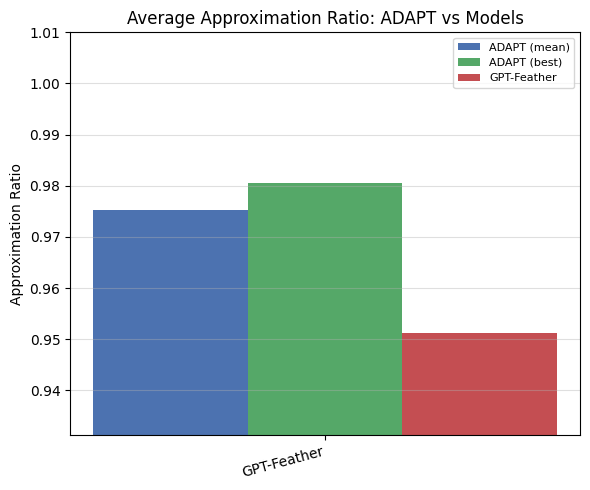

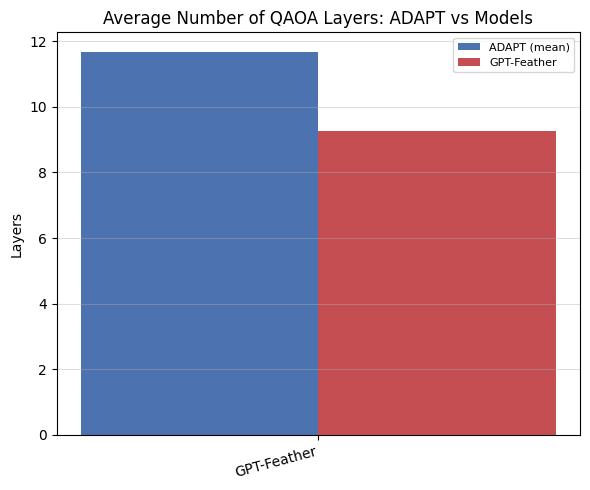

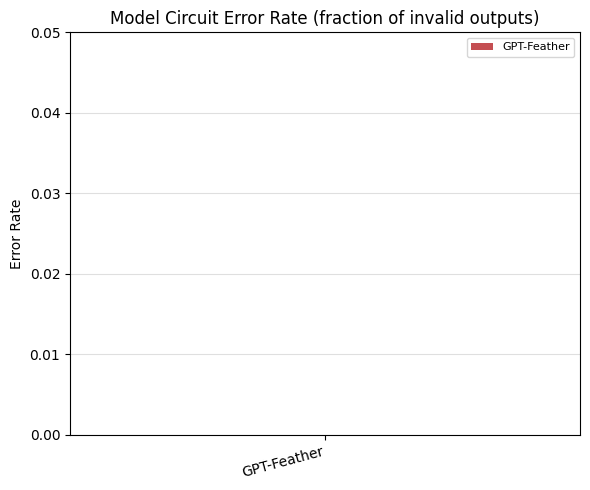

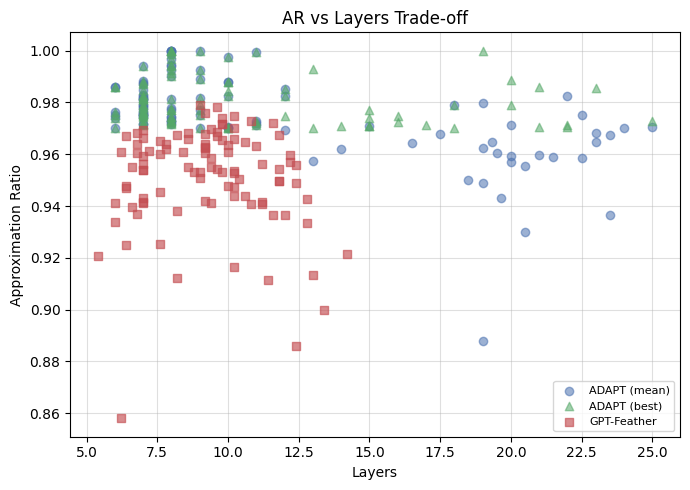

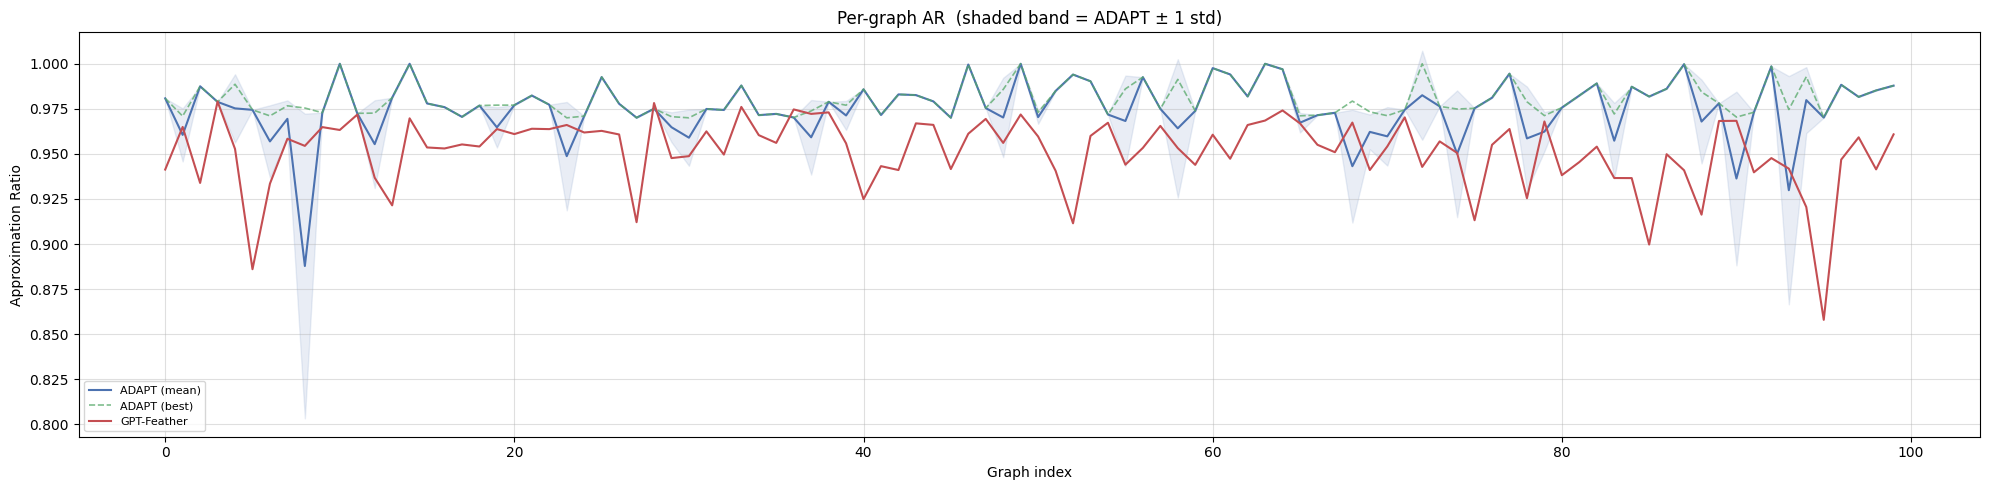

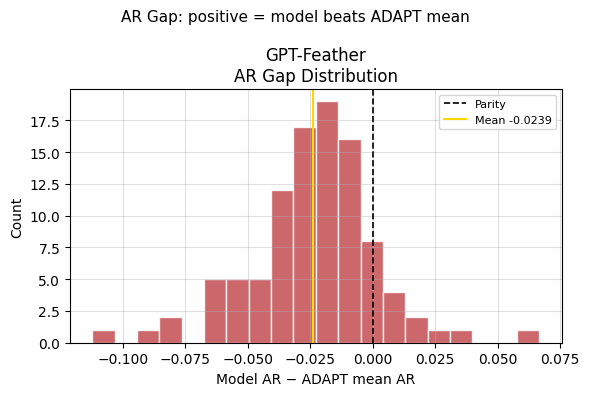

In [78]:

# ── Run all plots ──────────────────────────────────────────────────────────

plot_ar_bar(summary_df)
plot_layers_bar(summary_df)
plot_error_rate_bar(summary_df)
plot_ar_vs_layers_scatter(final_df)
plot_per_graph_ar(final_df)
plot_ar_gap_hist(final_df)

In [76]:
# ------------------------
# EXTRA INSIGHTS
# ------------------------

print("=" * 55)
print("INSIGHTS")
print("=" * 55)

for _, row in summary_df.iterrows():
    print(f"\nModel : {row['model']}")
    print(f"  Graphs evaluated      : {int(row['n_graphs'])}")
    print(f"  ADAPT AR (mean / best): {row['adapt_ar_mean']:.4f} / {row['adapt_ar_best']:.4f}")
    print(f"  Model AR              : {row['model_ar']:.4f}")
    print(f"  AR diff vs mean       : {row['ar_diff_vs_mean']:+.4f}")
    print(f"  AR diff vs best       : {row['ar_diff_vs_best']:+.4f}")
    print(f"  ADAPT layers (mean)   : {row['adapt_layers']:.2f}")
    print(f"  Model layers          : {row['model_layers']:.2f}")
    print(f"  Layer reduction       : {row['adapt_layers'] - row['model_layers']:+.2f}")
    print(f"  Model error rate      : {row['model_error_rate']:.4f}")

n_model_wins_mean = (final_df["ar_diff_vs_mean"] > 0).sum()
n_model_wins_best = (final_df["ar_diff_vs_best"] > 0).sum()
print(f"\n  Graphs where model > ADAPT mean : {n_model_wins_mean} / {len(final_df)}")
print(f"  Graphs where model > ADAPT best : {n_model_wins_best} / {len(final_df)}")

INSIGHTS

Model : GPT-Feather
  Graphs evaluated      : 100
  ADAPT AR (mean / best): 0.9752 / 0.9806
  Model AR              : 0.9513
  AR diff vs mean       : -0.0239
  AR diff vs best       : -0.0293
  ADAPT layers (mean)   : 11.69
  Model layers          : 9.27
  Layer reduction       : +2.42
  Model error rate      : 0.0000

  Graphs where model > ADAPT mean : 12 / 100
  Graphs where model > ADAPT best : 3 / 100
